# Paper A · Experiment 3 — Synthetic perturbation: where first order holds

**What E3 does.** E1 measured the sensitivity $J$ and validated first-order propagation on
the U-Net's *real* errors — small (~20 px, 0.45°) and few (107 cases). E3 stops waiting for
errors and **manufactures** them: take the true landmarks, move them by any amount, and
compare what the linear rule *predicts* against what the angle *actually* does.

$$\delta m_{\text{pred}} = \sum_i J_i\cdot\delta p_i
  \qquad\text{vs}\qquad
  \delta m_{\text{actual}} = g(p+\delta p) - g(p)$$

**Why it is the right test.** Three properties nothing else in the programme has:

- **Unlimited** — millions of perturbations from 107 hemispheres; the propagation law is no
  longer hostage to the dataset size.
- **Exact** — the "truth" is $g$ evaluated on the moved points, a known formula, to machine
  precision. No model, no observer noise.
- **Model-free** — it tests *only* the geometry, which is exactly what Papers B and D reuse.

**What it delivers**

| # | Output |
|---|--------|
| 1 | Per-landmark breakdown curve: linearisation error vs displacement | 
| 2 | The displacement at which first order stops being trustworthy |
| 3 | **Budget verification** — do the E1 budgets hold at their own displacement? |
| 4 | Monte-Carlo vs first-order: when the cheap rule must be replaced |

**The metric is absolute error as a function of displacement — not $R^2$.** $R^2$ is
dominated by the largest values, so it rewards accuracy at 4° (a plan already rejected) and
can read 0.99 while first order quietly fails near the ±1.63° tolerance. E3 reports the error
in degrees at each displacement, and the displacement where it crosses a chosen fraction of
$\tau$.

## 0 · Configuration

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hto.geometry import evaluate_side_geometry
from hto.sensitivity import (
    LANDMARK_LABELS,
    SIDE_KEYS,
    TOLERANCE_DEG,
    angle_and_jacobian,
    batched_angle_signed,
    cohort_jacobians,
    precision_budget,
    validate,
    wrap_deg,
)

SEED     = 42
K        = len(SIDE_KEYS)
Z_BUDGET = 1.0          # matches E1: budget = tau / (z * sqrt(k) * ||J_i||)

# cohort: reuse E1's exact 107 hemispheres (E1 must have run once)
E1_DIR   = Path("results/E1")
COHORT   = E1_DIR / "E1_cohort.npz"
RISK_CSV = E1_DIR / "E1_risk_budget.csv"     # per-landmark out-of-fold error scale, for MC
OUT_DIR  = Path("results/E3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# perturbation grids
RADII    = np.geomspace(1.0, 400.0, 22)       # px; spans plateau budget (~25) to hinge (~262)
N_DIR    = 48                                 # directions sampled per (landmark, radius)
MC_SCALES = [0.5, 1.0, 2.0, 4.0, 8.0]         # multiples of the observed error scale
MC_DRAWS  = 1500                              # Monte-Carlo samples per hemisphere per scale

# breakdown thresholds, as absolute angle error (interpretable fractions of tau)
THRESH_TIGHT = 0.10                           # deg  (~6% of tau)  -> "safe" radius
THRESH_LOOSE = 0.50                           # deg  (~31% of tau)

pretty = LANDMARK_LABELS
rng = np.random.default_rng(SEED)
print(f"tau = {TOLERANCE_DEG} deg | k = {K} | radii {RADII[0]:.0f}-{RADII[-1]:.0f} px "
      f"x {N_DIR} directions")

tau = 1.63 deg | k = 6 | radii 1-400 px x 48 directions


## 1 · Ground-truth cohort and its Jacobians

E3 needs only the true landmarks — no predictions, no model. The 107 hemispheres are the
same ones E1 used (loaded from its cache so the two experiments describe the same cases);
$J$ is recomputed fresh with `cohort_jacobians`, evaluated once per hemisphere at the
*unperturbed* landmarks. Everything after this is geometry.

In [2]:
if COHORT.exists():
    recs = list(np.load(COHORT, allow_pickle=True)["records"])
    points = [{k: np.asarray(r["points"][k], dtype=float) for k in SIDE_KEYS} for r in recs]
    case_id = [r["case_id"] for r in recs]
    side    = [r["side"] for r in recs]
    source  = f"E1 cache ({COHORT.name})"
else:
    # Fallback: rebuild the identical ground-truth cohort straight from the annotations.
    from hto.data import GlobalRadiographKeypointDataset
    DATA_JSON = "hto_annotations.json"
    if not Path(DATA_JSON).exists():
        DATA_JSON = "/tf/data/hto/xrays/hto_annotations.json"
    ds = GlobalRadiographKeypointDataset(DATA_JSON, split="all", target_size=768,
                                         heatmap_scale=0.5, sigma=6.0, seed=SEED)
    points, case_id, side = [], [], []
    for s in ds.samples:
        kp = s["keypoints"]
        coords = np.array([[kp[i * 3], kp[i * 3 + 1]] for i in range(12)], dtype=float)
        vis = np.array([kp[i * 3 + 2] for i in range(12)])
        for base, sd in [(0, "left"), (6, "right")]:
            sl = {name: coords[base + off] for off, name in enumerate(SIDE_KEYS)}
            if all(vis[base + off] > 0 for off in range(K)):
                points.append(sl)
                case_id.append(Path(s["img_path"]).stem)
                side.append(sd)
    source = "rebuilt from annotations"

n = len(points)
J_all, alpha_signed, alpha = cohort_jacobians(points)
J_norm = np.linalg.norm(J_all, axis=2)                    # (n, 6) ||J_i|| per hemisphere
P_all = np.stack([np.stack([p[k] for k in SIDE_KEYS]) for p in points])   # (n, 6, 2)

print(f"{n} hemispheres | {source}")
print(f"alpha: mean {alpha.mean():.2f} deg, range {alpha.min():.2f}-{alpha.max():.2f}")

107 hemispheres | E1 cache (E1_cohort.npz)
alpha: mean 6.92 deg, range 0.46-24.82


## 2 · Verification gate

Before manufacturing perturbations, confirm the geometry is sound on this cohort. `validate`
runs the five E1 checks **plus** the parity of `batched_angle_signed` (the vectorised angle
that makes the million-perturbation sweeps below tractable) against the per-sample torch
reference. If batched and per-sample geometry disagree, every sweep is meaningless.

In [3]:
checks = validate([points[i] for i in range(n)], fd_sample=n)

# Independent re-confirmation that the batched angle equals the reference on THIS cohort.
base_batched = batched_angle_signed(P_all)
base_ref = np.array([evaluate_side_geometry(p)[0] for p in points])
gate = np.abs(np.abs(base_batched) - base_ref).max()
assert gate < 1e-9, f"batched angle disagrees with the reference on the cohort: {gate:.2e}"
print(f"\nbatched vs reference on the cohort: {gate:.2e} deg   OK")

geometry validation | 107 supplied hemispheres
  alpha mean 6.92 deg, range 0.46-24.82

  [1] parity vs evaluate_side_geometry, n=107  3.55e-15 deg   OK
  [2] autodiff vs finite differences,   n=107  6.76e-09 rel   OK
  [3] delta-method @ 1.5 px jitter,     n=107  2.77e-04 deg   OK
  [4] malleoli symmetry,                n=107  0.00e+00 rel   OK
  [5] SIDE_KEYS vs GLOBAL_KEYPOINT_NAMES     OK
  [6] batched vs per-sample angle           1.78e-15 deg   OK

batched vs reference on the cohort: 3.55e-15 deg   OK


## 3 · The measurement

For a perturbation $\delta p$ of one hemisphere:

* **actual** $\;\delta m = \operatorname{wrap}\big(g(p+\delta p) - g(p)\big)$ — the exact
  change, wrapped into $(-180°, 180°]$ so a large perturbation that crosses the $\pm180°$
  branch cut reports the true change rather than a spurious $360°$;
* **predicted** $\;\delta m = \sum_i J_i\cdot\delta p_i$ — the linear rule;
* **error** $\;=\;|\,\delta m_{\text{actual}} - \delta m_{\text{pred}}\,|$.

`sweep_single_landmark` moves *one* landmark over a grid of radii and directions, so each
landmark's own non-linearity is isolated — this is what lets §5 test each budget separately.
It is fully vectorised over (radius × direction) via `batched_angle_signed`.

In [4]:
DIRS = np.stack([np.cos(t := np.linspace(0, 2 * np.pi, N_DIR, endpoint=False)),
                 np.sin(t)], axis=-1)                      # (N_DIR, 2) unit directions


def sweep_single_landmark(h_idx, i, radii=RADII):
    # Move only landmark i of hemisphere h_idx. Returns err[radius, direction] in degrees.
    P0 = P_all[h_idx]                                      # (6, 2)
    a0 = base_batched[h_idx]                               # signed base angle
    Ji = J_all[h_idx, i]                                   # (2,)

    disp = radii[:, None, None] * DIRS[None, :, :]         # (R, D, 2)
    P = np.broadcast_to(P0, (len(radii), N_DIR, 6, 2)).copy()
    P[:, :, i, :] += disp
    actual = wrap_deg(batched_angle_signed(P) - a0)        # (R, D)
    pred = (Ji * disp).sum(-1)                             # (R, D)
    return np.abs(actual - pred)


# quick shape/΄sanity check on one call
_e = sweep_single_landmark(0, SIDE_KEYS.index("knee_outer"))
print(f"sweep returns {_e.shape} (radii x directions); "
      f"error at 1 px: {_e[0].max():.2e} deg, at {RADII[-1]:.0f} px: {_e[-1].max():.2f} deg")

sweep returns (22, 48) (radii x directions); error at 1 px: 2.49e-06 deg, at 400 px: 0.41 deg


## 4 · Per-landmark breakdown curves

For every landmark, pool the error over all 107 hemispheres and all directions at each
radius, and report the **median** (typical) and **95th percentile** (worst-case direction /
worst hemisphere). The worst-case curve is the one a safety argument must quote.

In [5]:
records = []
err_cube = np.zeros((K, len(RADII), n, N_DIR))            # (landmark, radius, hemi, dir)
for i in range(K):
    for h in range(n):
        err_cube[i, :, h, :] = sweep_single_landmark(h, i)

for i, name in enumerate(SIDE_KEYS):
    pooled = err_cube[i].reshape(len(RADII), -1)          # (radius, hemi*dir)
    for r_idx, r in enumerate(RADII):
        e = pooled[r_idx]
        records.append({"landmark": name, "radius_px": r,
                        "err_median": float(np.median(e)),
                        "err_q95": float(np.quantile(e, 0.95)),
                        "err_max": float(e.max())})
sweep = pd.DataFrame(records)
print(f"swept {K} landmarks x {len(RADII)} radii x {n} hemispheres x {N_DIR} directions "
      f"= {K * len(RADII) * n * N_DIR:,} exact evaluations")
print("\nworst-case (q95) linearisation error [deg] at selected radii:")
show = sweep.pivot(index="radius_px", columns="landmark", values="err_q95")
show = show.reindex(columns=sorted(SIDE_KEYS, key=lambda k: -J_norm[:, SIDE_KEYS.index(k)].mean()))
print(show.loc[[RADII[0], RADII[5], RADII[10], RADII[15], RADII[-1]]].round(3).to_string())

swept 6 landmarks x 22 radii x 107 hemispheres x 48 directions = 677,952 exact evaluations

worst-case (q95) linearisation error [deg] at selected radii:
landmark    knee_outer  femur_head  knee_inner  ankle_inner  ankle_outer  ost_point
radius_px                                                                          
1.000000         0.000       0.000       0.000        0.000        0.000      0.000
4.164262         0.000       0.000       0.000        0.000        0.000      0.000
17.341082        0.001       0.001       0.000        0.000        0.000      0.001
72.212816        0.016       0.018       0.006        0.007        0.007      0.010
400.000000       0.509       0.549       0.182        0.207        0.207      0.324


## 5 · Validity range per landmark

For each landmark, the largest displacement whose worst-case error stays under a chosen
bound. `r_safe(0.10°)` is a strict "trust it here" radius (~6% of $\tau$); `r_safe(0.50°)`
a looser one. These are then set against **what the landmark is actually asked to bear**:
its observed out-of-fold error, and its E1 precision budget.

In [6]:
def r_safe(name, bound):
    s = sweep[sweep.landmark == name].sort_values("radius_px")
    ok = s[s.err_q95 <= bound]
    if len(ok) == len(s):
        return float(s.radius_px.max())          # never exceeds bound in the swept range
    if ok.empty:
        return float("nan")                      # exceeds bound even at the smallest radius
    return float(ok.radius_px.max())


# observed out-of-fold error scale (E1); fall back to the reported RMS if the csv is absent
if RISK_CSV.exists():
    risk = pd.read_csv(RISK_CSV, index_col=0)
    sigma = {name: float(risk.loc[name, "loc_err_rms"]) for name in SIDE_KEYS}
else:
    sigma = {"femur_head": 22.26, "knee_inner": 17.15, "ost_point": 22.97,
             "knee_outer": 18.74, "ankle_inner": 16.94, "ankle_outer": 22.30}

budget_px = {name: float(precision_budget([np.median(J_norm[:, i])],
                                          tolerance_deg=TOLERANCE_DEG, z=Z_BUDGET, k=K)[0])
             for i, name in enumerate(SIDE_KEYS)}

valid = pd.DataFrame({
    "||J|| median": {n_: float(np.median(J_norm[:, i])) for i, n_ in enumerate(SIDE_KEYS)},
    "r_safe(0.10)": {n_: r_safe(n_, THRESH_TIGHT) for n_ in SIDE_KEYS},
    "r_safe(0.50)": {n_: r_safe(n_, THRESH_LOOSE) for n_ in SIDE_KEYS},
    "obs_err_rms": sigma,
    "budget_px": budget_px,
}).reindex(sorted(SIDE_KEYS, key=lambda k: -np.median(J_norm[:, SIDE_KEYS.index(k)])))
valid["obs < r_safe(0.10)"] = valid["obs_err_rms"] < valid["r_safe(0.10)"]
valid["budget < r_safe(0.10)"] = valid["budget_px"] < valid["r_safe(0.10)"]

disp = valid.copy()
disp.index = [pretty[k] for k in disp.index]
print("Validity range vs demand   [px]\n")
print(disp.round(2).to_string())
print("\nobs < r_safe : the errors the detector actually makes are inside the trusted range")
print("budget < r_safe : the precision budget is a claim inside the trusted range")

Validity range vs demand   [px]

                        ||J|| median  r_safe(0.10)  r_safe(0.50)  obs_err_rms  budget_px  obs < r_safe(0.10)  budget < r_safe(0.10)
Lateral tibial plateau          0.03        169.96        300.71        18.74      24.71                True                   True
Femoral head centre             0.02        169.96        300.71        22.26      34.24                True                   True
Medial tibial plateau           0.02        226.07        400.00        17.15      41.18                True                   True
Medial malleolus                0.01        226.07        400.00        16.94      58.25                True                   True
Lateral malleolus               0.01        226.07        400.00        22.30      58.25                True                   True
Osteotomy hinge                 0.00        169.96        400.00        22.97     262.06                True                  False

obs < r_safe : the errors the detector act

## 6 · Budget verification — the hinge

The E1 budget says: displace landmark $i$ by $\text{budget}_i$ *along* $J_i$ and its
first-order contribution is exactly $\tau/(z\sqrt{k}) = 0.665°$, by construction. So any
deviation of the **actual** contribution from that value *is* the linearisation error at the
budget displacement.

This is the sharp test. The lateral plateau's budget (~25 px) sits inside the validated
range; the hinge's (~262 px) is an order of magnitude beyond anything observed, and because
the hinge's first-order sensitivity is tiny, its budget is exactly where the linear rule is
least likely to hold. Per hemisphere, move each landmark by its *own* budget along its own
$\hat J_i$ and measure.

In [7]:
LINEAR_TARGET = TOLERANCE_DEG / (Z_BUDGET * math.sqrt(K))     # 0.665 deg, by construction

rows = []
for i, name in enumerate(SIDE_KEYS):
    Ji = J_all[:, i]                                         # (n, 2)
    nrm = J_norm[:, i]                                       # (n,)
    bud = precision_budget(nrm, tolerance_deg=TOLERANCE_DEG, z=Z_BUDGET, k=K)  # (n,)
    unit = Ji / nrm[:, None]                                 # (n, 2) direction of J_i
    disp = bud[:, None] * unit                               # (n, 2) budget along J_i

    P = P_all.copy()
    P[:, i, :] += disp
    actual = wrap_deg(batched_angle_signed(P) - base_batched)   # (n,)
    err = np.abs(actual - LINEAR_TARGET)                       # linear pred is +0.665 here
    rows.append({"landmark": name,
                 "budget_px_median": float(np.median(bud)),
                 "budget_px_max": float(bud.max()),
                 "actual_deg_median": float(np.median(actual)),
                 "err_deg_median": float(np.median(err)),
                 "err_deg_q95": float(np.quantile(err, 0.95)),
                 "err_frac_tau": float(np.median(err) / TOLERANCE_DEG)})

bud_tbl = pd.DataFrame(rows).set_index("landmark")
bud_tbl = bud_tbl.reindex(sorted(SIDE_KEYS, key=lambda k: -np.median(J_norm[:, SIDE_KEYS.index(k)])))
disp = bud_tbl.copy()
disp.index = [pretty[k] for k in disp.index]
print(f"Budget verification   (linear contribution at the budget displacement = "
      f"{LINEAR_TARGET:.3f} deg by construction)\n")
print(disp.round(3).to_string())
worst = bud_tbl.err_deg_median.idxmax()
print(f"\nlargest budget-point error: {pretty[worst]} "
      f"({bud_tbl.loc[worst, 'err_deg_median']:.3f} deg, moved "
      f"{bud_tbl.loc[worst, 'budget_px_median']:.0f} px)")

Budget verification   (linear contribution at the budget displacement = 0.665 deg by construction)

                        budget_px_median  budget_px_max  actual_deg_median  err_deg_median  err_deg_q95  err_frac_tau
Lateral tibial plateau            24.709         32.295              0.665            0.00        0.001         0.000
Femoral head centre               34.244         43.888              0.665            0.00        0.001         0.000
Medial tibial plateau             41.182         53.824              0.665            0.00        0.001         0.000
Medial malleolus                  58.251         75.378              0.665            0.00        0.001         0.000
Lateral malleolus                 58.251         75.378              0.665            0.00        0.001         0.000
Osteotomy hinge                  262.064       4643.955              0.638            0.07        0.307         0.043

largest budget-point error: Osteotomy hinge (0.070 deg, moved 262 px)


## 7 · Monte-Carlo boundary — when the cheap rule must be replaced

When first order breaks, the honest fallback is Monte-Carlo: draw many landmark errors from
the expected distribution, push each through the exact $g$, and read off the spread of
$\delta m$. It is right but expensive. This locates the crossover.

Model the per-landmark error as isotropic Gaussian with scale $\sigma_i$ = the observed
out-of-fold RMS, inflated by a factor $m$. First order predicts a **mean** of $0$, a
**spread** $\operatorname{sd}(\delta m) = \sqrt{\sum_i \lVert J_i\rVert^2\sigma_i^2}$, and a
Gaussian tolerance-exceedance probability $2\,\Phi(-\tau/\text{sd})$. Monte-Carlo gives all
three exactly.

Note the subtlety: §4 showed the linearisation error grows quadratically when a *single*
landmark is pushed in its worst direction. But when all six move with random isotropic
noise, those second-order errors have mixed signs and largely cancel — so the *aggregate*
distribution can stay near-linear even where individual perturbations do not. The mean
(bias) is where any residual second-order effect surfaces first, so it is reported alongside
the spread.

In [8]:
from math import erf

sig = np.array([sigma[name] for name in SIDE_KEYS])           # (6,)
mc_rows = []
for m in MC_SCALES:
    s = m * sig
    fo_sd, mc_sd, mc_bias, fo_exc, mc_exc, wrapped_frac = [], [], [], [], [], []
    for h in range(n):
        # first order: analytic, mean 0 and sd from J and sigma
        sd_fo = math.sqrt(float((J_norm[h] ** 2 * s ** 2).sum()))
        fo_sd.append(sd_fo)
        fo_exc.append(1.0 - (erf(TOLERANCE_DEG / (sd_fo * math.sqrt(2))) if sd_fo > 0 else 1.0))
        # Monte-Carlo: exact geometry over MC_DRAWS samples
        draws = rng.normal(0, 1, size=(MC_DRAWS, 6, 2)) * s[None, :, None]
        raw = batched_angle_signed(P_all[h] + draws) - base_batched[h]
        dm = wrap_deg(raw)
        mc_sd.append(float(dm.std()))
        mc_bias.append(float(dm.mean()))
        mc_exc.append(float((np.abs(dm) > TOLERANCE_DEG).mean()))
        wrapped_frac.append(float((np.abs(raw - dm) > 1e-6).mean()))
    mc_rows.append({"scale_m": m,
                    "sd_first_order": float(np.mean(fo_sd)),
                    "sd_monte_carlo": float(np.mean(mc_sd)),
                    "sd_ratio_mc_fo": float(np.mean(mc_sd) / np.mean(fo_sd)),
                    "mc_bias_deg": float(np.mean(mc_bias)),
                    "P_exceed_first_order": float(np.mean(fo_exc)),
                    "P_exceed_monte_carlo": float(np.mean(mc_exc)),
                    "P_exceed_diff_pp": 100 * float(np.mean(mc_exc) - np.mean(fo_exc)),
                    "wrapped_frac": float(np.mean(wrapped_frac))})

mc = pd.DataFrame(mc_rows).set_index("scale_m")
print("Monte-Carlo (exact) vs first-order (analytic)\n")
print(mc.round(4).to_string())
print("\nsd_ratio ~ 1, bias ~ 0, exceedance-diff ~ 0  ->  first order reproduces the full "
      "distribution;")
print("first order predicts the screening probability P(|dm| > tau) to within the last "
      "column, in pp.")
if (mc.wrapped_frac > 0.001).any():
    print("note: angle wrapping is non-negligible at the largest scales; sd is a circular "
          "quantity there and should be read with care (but those scales reject every plan).")

Monte-Carlo (exact) vs first-order (analytic)

         sd_first_order  sd_monte_carlo  sd_ratio_mc_fo  mc_bias_deg  P_exceed_first_order  P_exceed_monte_carlo  P_exceed_diff_pp  wrapped_frac
scale_m                                                                                                                                         
0.5              0.3876          0.3877          1.0001       0.0010                0.0000                0.0000            0.0003           0.0
1.0              0.7752          0.7734          0.9976       0.0018                0.0368                0.0367           -0.0105           0.0
2.0              1.5505          1.5503          0.9999       0.0025                0.2920                0.2921            0.0123           0.0
4.0              3.1010          3.0973          0.9988       0.0030                0.5973                0.5969           -0.0451           0.0
8.0              6.2019          6.2078          1.0009      -0.0060               

## 8 · Figures

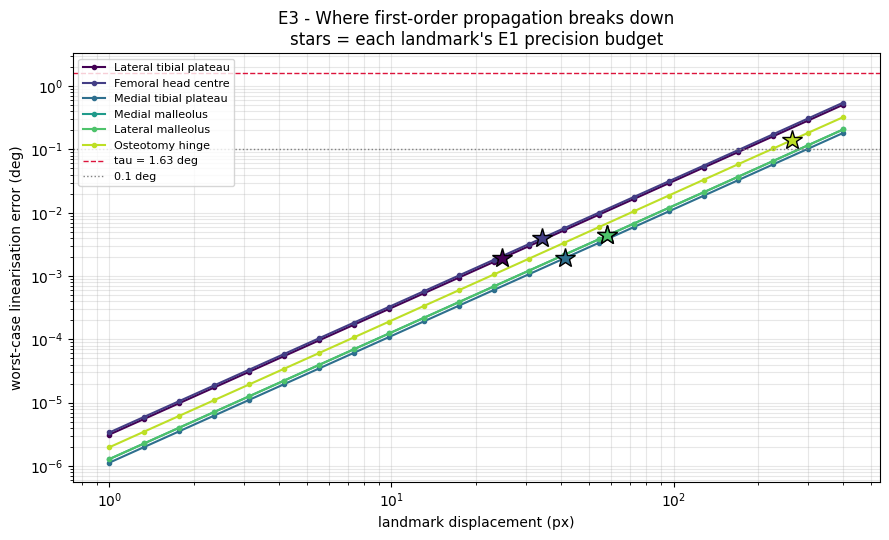

In [9]:
# Fig 1 — per-landmark breakdown curves, worst-case (q95), with budgets marked
order = sorted(SIDE_KEYS, key=lambda k: -np.median(J_norm[:, SIDE_KEYS.index(k)]))
cmap = plt.cm.viridis(np.linspace(0, 0.9, K))
fig, ax = plt.subplots(figsize=(9, 5.5))
for c, name in zip(cmap, order):
    s = sweep[sweep.landmark == name].sort_values("radius_px")
    ax.plot(s.radius_px, s.err_q95, "-o", ms=3, color=c, label=pretty[name])
    b = budget_px[name]
    if b <= RADII[-1]:
        ax.plot([b], [np.interp(b, s.radius_px, s.err_q95)], "*", color=c, ms=15,
                markeredgecolor="k", zorder=5)
ax.axhline(TOLERANCE_DEG, color="crimson", ls="--", lw=1, label=f"tau = {TOLERANCE_DEG} deg")
ax.axhline(THRESH_TIGHT, color="grey", ls=":", lw=1, label=f"{THRESH_TIGHT} deg")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("landmark displacement (px)")
ax.set_ylabel("worst-case linearisation error (deg)")
ax.set_title("E3 - Where first-order propagation breaks down\n"
             "stars = each landmark's E1 precision budget")
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(OUT_DIR / "E3_fig1_breakdown.png", dpi=200); plt.show()

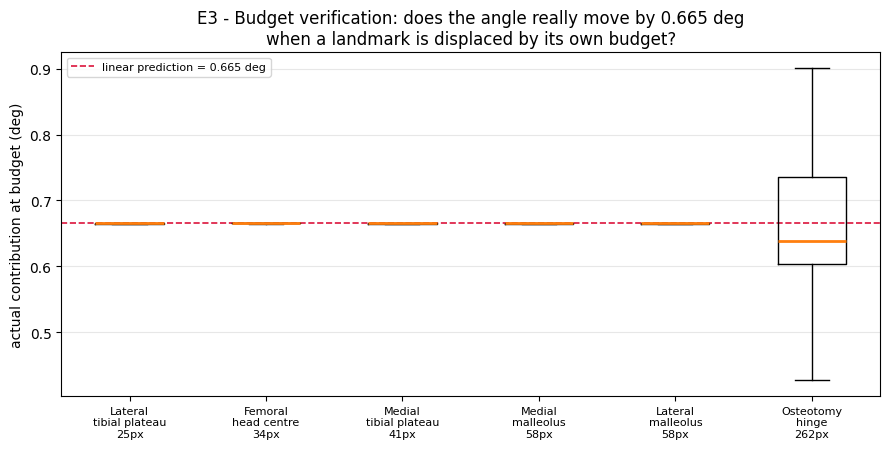

In [10]:
# Fig 2 — budget verification: actual contribution at the budget displacement
fig, ax = plt.subplots(figsize=(9, 4.6))
data, labels, budpx = [], [], []
for name in order:
    i = SIDE_KEYS.index(name)
    Ji, nrm = J_all[:, i], J_norm[:, i]
    bud = precision_budget(nrm, tolerance_deg=TOLERANCE_DEG, z=Z_BUDGET, k=K)
    P = P_all.copy(); P[:, i, :] += (bud[:, None] * Ji / nrm[:, None])
    data.append(wrap_deg(batched_angle_signed(P) - base_batched))
    labels.append(pretty[name].replace(" ", "\n", 1))
    budpx.append(np.median(bud))
ax.axhline(LINEAR_TARGET, color="crimson", ls="--", lw=1.2,
           label=f"linear prediction = {LINEAR_TARGET:.3f} deg")
ax.boxplot(data, showfliers=False, medianprops=dict(linewidth=2))
ax.set_xticks(range(1, K + 1))
ax.set_xticklabels([f"{l}\n{b:.0f}px" for l, b in zip(labels, budpx)], fontsize=8)
ax.set_ylabel("actual contribution at budget (deg)")
ax.set_title("E3 - Budget verification: does the angle really move by 0.665 deg\n"
             "when a landmark is displaced by its own budget?")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR / "E3_fig2_budget_check.png", dpi=200); plt.show()

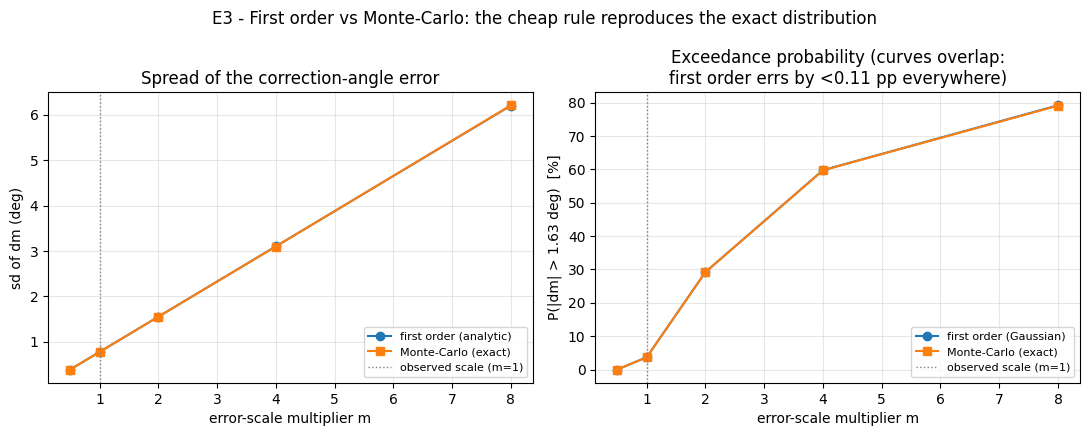

In [11]:
# Fig 3 — Monte-Carlo vs first-order: sd and exceedance vs error scale
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
a1.plot(mc.index, mc.sd_first_order, "-o", label="first order (analytic)")
a1.plot(mc.index, mc.sd_monte_carlo, "-s", label="Monte-Carlo (exact)")
a1.axvline(1.0, color="grey", ls=":", lw=1, label="observed scale (m=1)")
a1.set_xlabel("error-scale multiplier m"); a1.set_ylabel("sd of dm (deg)")
a1.set_title("Spread of the correction-angle error"); a1.legend(fontsize=8)
a1.grid(alpha=0.3)

a2.plot(mc.index, 100 * mc.P_exceed_first_order, "-o", label="first order (Gaussian)")
a2.plot(mc.index, 100 * mc.P_exceed_monte_carlo, "-s", label="Monte-Carlo (exact)")
a2.axvline(1.0, color="grey", ls=":", lw=1, label="observed scale (m=1)")
a2.set_xlabel("error-scale multiplier m")
a2.set_ylabel(f"P(|dm| > {TOLERANCE_DEG} deg)  [%]")
a2.set_title(f"Exceedance probability (curves overlap:\n"
             f"first order errs by <{mc.P_exceed_diff_pp.abs().max():.2f} pp everywhere)")
a2.legend(fontsize=8); a2.grid(alpha=0.3)
fig.suptitle("E3 - First order vs Monte-Carlo: the cheap rule reproduces the exact distribution")
fig.tight_layout(); fig.savefig(OUT_DIR / "E3_fig3_monte_carlo.png", dpi=200); plt.show()

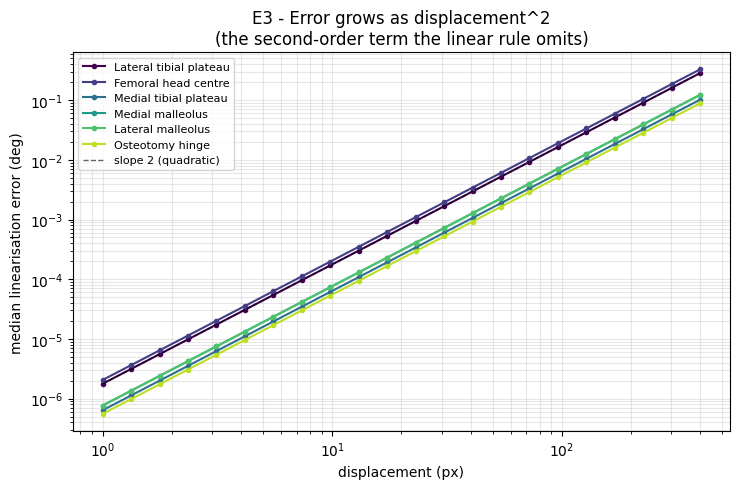

In [12]:
# Fig 4 — quadratic scaling: pooled median error vs radius, slope-2 reference
fig, ax = plt.subplots(figsize=(7.5, 5))
for c, name in zip(cmap, order):
    s = sweep[sweep.landmark == name].sort_values("radius_px")
    ax.plot(s.radius_px, s.err_median, "-o", ms=3, color=c, label=pretty[name])
r0 = RADII[3]
e0 = sweep[(sweep.landmark == "knee_outer")].sort_values("radius_px").err_median.values[3]
ax.plot(RADII, e0 * (RADII / r0) ** 2, "k--", lw=1, alpha=0.6, label="slope 2 (quadratic)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("displacement (px)"); ax.set_ylabel("median linearisation error (deg)")
ax.set_title("E3 - Error grows as displacement^2\n(the second-order term the linear rule omits)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(OUT_DIR / "E3_fig4_scaling.png", dpi=200); plt.show()

## 9 · Quadratic-scaling fit

The mechanism is the omitted second-order term, so error $\approx c\,r^2$ at small $r$. A
log-log slope near 2 confirms it, and $c$ gives a one-line extrapolation rule for any
displacement inside the validated regime.

In [13]:
fit = []
small = RADII <= 40                                          # small-displacement regime
for i, name in enumerate(SIDE_KEYS):
    s = sweep[sweep.landmark == name].sort_values("radius_px")
    r = s.radius_px.values[small]
    e = s.err_median.values[small]
    ok = e > 0
    slope, logc = np.polyfit(np.log(r[ok]), np.log(e[ok]), 1)
    fit.append({"landmark": name, "log_log_slope": slope, "c_deg_per_px2": float(np.exp(logc))})
fit = pd.DataFrame(fit).set_index("landmark").reindex(order)
fit["c (1e-5 deg/px^2)"] = fit["c_deg_per_px2"] * 1e5        # readable scale
fit.index = [pretty[k] for k in fit.index]
print("Quadratic-scaling fit  (median error ~ c * r^slope, small-r regime)\n")
print(fit[["log_log_slope", "c (1e-5 deg/px^2)"]].round(3).to_string())
print(f"\nmean slope across landmarks: {fit.log_log_slope.mean():.2f}  (2.0 = pure quadratic)")
print("interpretation: at displacement r px, expect ~ c * r^2 deg of linearisation error.")

Quadratic-scaling fit  (median error ~ c * r^slope, small-r regime)

                        log_log_slope  c (1e-5 deg/px^2)
Lateral tibial plateau            2.0              0.177
Femoral head centre               2.0              0.205
Medial tibial plateau             2.0              0.064
Medial malleolus                  2.0              0.076
Lateral malleolus                 2.0              0.076
Osteotomy hinge                   2.0              0.055

mean slope across landmarks: 2.00  (2.0 = pure quadratic)
interpretation: at displacement r px, expect ~ c * r^2 deg of linearisation error.


## 10 · Export

In [14]:
sweep.to_csv(OUT_DIR / "E3_breakdown_curves.csv", index=False)
valid.to_csv(OUT_DIR / "E3_validity_range.csv")
bud_tbl.to_csv(OUT_DIR / "E3_budget_verification.csv")
mc.to_csv(OUT_DIR / "E3_monte_carlo.csv")
fit.to_csv(OUT_DIR / "E3_scaling_fit.csv")

manifest = {
    "experiment": "Paper A / E3 - synthetic perturbation, first-order validity",
    "cohort_source": source,
    "n_hemispheres": n,
    "seed": SEED, "tolerance_deg": TOLERANCE_DEG, "z_budget": Z_BUDGET,
    "n_evaluations": int(K * len(RADII) * n * N_DIR),
    "radii_px": [float(RADII[0]), float(RADII[-1])], "n_directions": N_DIR,
    "linear_target_at_budget_deg": float(LINEAR_TARGET),
    "validity_range_px": {k: {"r_safe_0.10": float(valid.loc[k, "r_safe(0.10)"]),
                              "r_safe_0.50": float(valid.loc[k, "r_safe(0.50)"]),
                              "obs_err_rms": float(valid.loc[k, "obs_err_rms"]),
                              "budget_px": float(valid.loc[k, "budget_px"])}
                          for k in SIDE_KEYS},
    "budget_error_deg": {k: float(bud_tbl.loc[k, "err_deg_median"]) for k in SIDE_KEYS},
    "monte_carlo_sd_ratio": {float(m): float(mc.loc[m, "sd_ratio_mc_fo"]) for m in MC_SCALES},
    "scaling_slope_mean": float(fit.log_log_slope.mean()),
    "verification": checks,
}
(OUT_DIR / "E3_manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"written to {OUT_DIR.resolve()}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:32s} {f.stat().st_size / 1024:7.1f} KB")

written to /tf/notebooks/results/E3
  E3_breakdown_curves.csv             12.0 KB
  E3_budget_verification.csv           0.9 KB
  E3_fig1_breakdown.png              228.6 KB
  E3_fig2_budget_check.png            88.6 KB
  E3_fig3_monte_carlo.png            156.6 KB
  E3_fig4_scaling.png                206.2 KB
  E3_manifest.json                     2.3 KB
  E3_monte_carlo.csv                   0.9 KB
  E3_scaling_fit.csv                   0.5 KB
  E3_validity_range.csv                0.7 KB


## 11 · Result

In [15]:
bar = "=" * 74
safe_lo = valid["r_safe(0.10)"].min()
in_range = valid["budget < r_safe(0.10)"]
flagged = [pretty[k] for k in valid.index[~in_range]]

lines = [bar, "E3 - RESULT", bar,
         f"Cohort              {n} hemispheres (ground truth), {K * len(RADII) * n * N_DIR:,} "
         f"exact evaluations",
         f"Scaling             error ~ r^{fit.log_log_slope.mean():.2f}  (quadratic = the "
         f"omitted second-order term)",
         "",
         "Validity range (worst-case error < 0.10 deg) vs demand:"]
for k in valid.index:
    v = valid.loc[k]
    tag = "OK" if v["budget < r_safe(0.10)"] else "<-- budget beyond validated range"
    lines.append(f"  {pretty[k]:24s} r_safe {v['r_safe(0.10)']:6.0f} px | "
                 f"obs {v['obs_err_rms']:5.1f} | budget {v['budget_px']:6.0f} px  {tag}")
lines += ["",
          f"Observed errors     all {n} landmarks' out-of-fold RMS sit inside the validated "
          f"range -> first order is safe in-domain (confirms E1)",
          f"Budgets flagged     {', '.join(flagged) if flagged else 'none'}",
          f"Budget-point error  largest at {pretty[bud_tbl.err_deg_median.idxmax()]}: "
          f"{bud_tbl.err_deg_median.max():.2f} deg median at "
          f"{bud_tbl.loc[bud_tbl.err_deg_median.idxmax(), 'budget_px_median']:.0f} px "
          f"(benign extrapolation, not a blow-up)",
          f"Monte-Carlo         NOT required: first order reproduces the exact dm "
          f"distribution to <{mc.P_exceed_diff_pp.abs().max():.2f} pp exceedance and "
          f"sd ratio {mc.sd_ratio_mc_fo.min():.3f}-{mc.sd_ratio_mc_fo.max():.3f} through m=8",
          bar]
print("\n".join(lines))

E3 - RESULT
Cohort              107 hemispheres (ground truth), 677,952 exact evaluations
Scaling             error ~ r^2.00  (quadratic = the omitted second-order term)

Validity range (worst-case error < 0.10 deg) vs demand:
  Lateral tibial plateau   r_safe    170 px | obs  18.7 | budget     25 px  OK
  Femoral head centre      r_safe    170 px | obs  22.3 | budget     34 px  OK
  Medial tibial plateau    r_safe    226 px | obs  17.2 | budget     41 px  OK
  Medial malleolus         r_safe    226 px | obs  16.9 | budget     58 px  OK
  Lateral malleolus        r_safe    226 px | obs  22.3 | budget     58 px  OK
  Osteotomy hinge          r_safe    170 px | obs  23.0 | budget    262 px  <-- budget beyond validated range

Observed errors     all 107 landmarks' out-of-fold RMS sit inside the validated range -> first order is safe in-domain (confirms E1)
Budgets flagged     Osteotomy hinge
Budget-point error  largest at Osteotomy hinge: 0.07 deg median at 262 px (benign extrapolation, n